# Spotify Hit Prediction - Modélisation

Ce notebook présente les différentes étapes de modélisation mises en œuvre pour prédire si un morceau peut devenir un **hit** à partir de ses caractéristiques audio.

Deux modèles de classification sont étudiés :
- La **régression logistique**, utilisée comme modèle de référence.
- **XGBoost**, un modèle plus complexe permettant de capturer des relations non linéaires entre les variables.

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LearningCurveDisplay, StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

## 2. Chargement des données prétraitées

In [2]:
X_train = pd.read_csv("/home/elodie/projet_audio/spotify-hit-analysis/data/X_train.csv")
X_test = pd.read_csv("/home/elodie/projet_audio/spotify-hit-analysis/data/X_test.csv")

y_train = pd.read_csv("/home/elodie/projet_audio/spotify-hit-analysis/data/y_train.csv")
y_test = pd.read_csv("/home/elodie/projet_audio/spotify-hit-analysis/data/y_test.csv")

# Modèle : Régression Logistique

La **régression logistique** est un modèle de classification linéaire largement utilisé comme référence grâce à sa simplicité, sa rapidité d'entraînement et sa bonne interprétabilité.

Dans ce projet, elle sert de modèle baseline afin d'établir un premier niveau de performance avant d'évaluer des modèles plus complexes.

La régression logistique est sensible à l'échelle des variables. Il est donc nécessaire de normaliser les variables numériques avant l'entraînement du modèle.

Sans normalisation, certaines variables comme `duration_ms` ou `tempo`, qui possèdent des valeurs plus élevées, pourraient avoir une influence disproportionnée sur l'optimisation du modèle.

In [3]:
numeric_cols = [
    "duration_ms",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Entraînement du modèle

In [4]:
model_log_reg = LogisticRegression(
    class_weight="balanced", random_state=42, max_iter=1000
)

model_log_reg.fit(X_train_scaled, y_train.squeeze())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [5]:
y_pred_log_reg = model_log_reg.predict(X_test_scaled)

## Évaluation des performances

In [6]:
print(classification_report(y_test, y_pred_log_reg))

              precision    recall  f1-score   support

       False       0.87      0.61      0.72     18114
        True       0.30      0.65      0.41      4686

    accuracy                           0.62     22800
   macro avg       0.59      0.63      0.56     22800
weighted avg       0.75      0.62      0.65     22800



Le modèle obtient une accuracy d'environ 62%.

Le rappel (recall) de la classe `is_hit` (= True) est assez élevé (65 %), ce qui signifie qu'une grande partie des morceaux à succès est correctement détectée. 

En revanche, la précision reste faible (30 %), ce qui traduit un nombre important de faux positifs. 

## Matrice de confusion

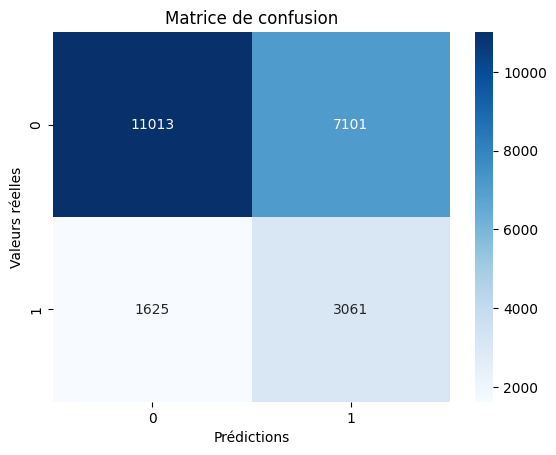

In [7]:
cm = confusion_matrix(y_test, y_pred_log_reg)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion")

plt.show()

La matrice de confusion confirme que le modèle détecte une majorité des hits, mais cela au prix d'un nombre élevé de faux positifs.

Ceci est cohérent avec l'utilisation du paramètre `class_weight="balanced"`, qui favorise la détection de la classe minoritaire.

## Vérification de la généralisation

Les performances sont comparées entre l'ensemble d'entraînement et le l'ensemble de test afin de détecter un éventuel surapprentissage (overfitting).

In [8]:
y_train_pred_log_reg = model_log_reg.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred_log_reg)
test_accuracy = accuracy_score(y_test, y_pred_log_reg)
train_f1 = f1_score(y_train, y_train_pred_log_reg)
test_f1 = f1_score(y_test, y_pred_log_reg)

print(f"Train accuracy : {train_accuracy:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Train F1-score : {train_f1:.4f}")
print(f"Test F1-score  : {test_f1:.4f}")

Train accuracy : 0.6196
Test accuracy : 0.6173
Train F1-score : 0.4137
Test F1-score  : 0.4123


Les performances sur l'ensemble d'entraînement et sur l'ensemble de test sont très proches.

L'absence d'écart important nous montre que le modèle généralise correctement et ne présente pas de surapprentissage (overfitting).

## Courbes d'apprentissage

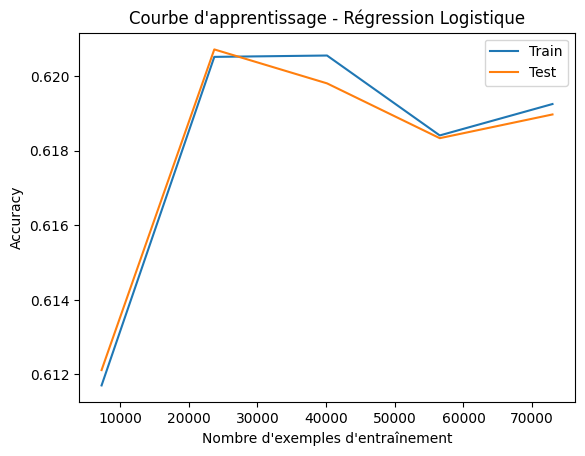

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

LearningCurveDisplay.from_estimator(
    model_log_reg,
    X_train_scaled,
    y_train.squeeze(),
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1,
    std_display_style=None,
)

plt.title("Courbe d'apprentissage - Régression Logistique")
plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("Accuracy")
plt.show()

Les courbes d'apprentissage montrent que les performances sur les ensembles d'entraînement et de validation convergent rapidement.

Le faible écart entre les deux courbes confirme une bonne capacité de généralisation. En revanche, leur plateau relativement bas suggère un léger underfitting : la régression logistique, en raison de sa nature linéaire, ne capture pas toute la complexité des relations présentes dans les données.

## Conclusion sur la régression logistique

La régression logistique permet d'obtenir un premier modèle de référence. Les performances sont correctes et les résultats sur les jeux d'entraînement et de test sont très proches, ce qui montre que le modèle généralise bien et ne présente pas d'overfitting.

En revanche, les performances restent limitées. Les courbes d'apprentissage montrent que le modèle atteint rapidement un plateau, signe qu'il ne parvient pas à capturer toute la complexité des données.

Pour tenter d'améliorer les prédictions, nous allons maintenant utiliser **XGBoost**, un modèle plus puissant, souvent très performant sur ce type de problème de classification.